In [5]:
import numpy  as np
import pandas as pd
import matplotlib.pyplot   as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
import sys

ROOT = Path('..').resolve()          # repo root (one level above notebooks/)
sys.path.insert(0, str(ROOT))        # enables: from src.config import ...

from src.config import (
    PROC_DATA_PATH, FIGURES_DIR,
    MODEL_FEATURES, LABEL_COL, ZONES, ZONE_COL
)

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
print(f'Dataset : {PROC_DATA_PATH}')
print(f'Figures → {FIGURES_DIR}')



Dataset : C:\Users\bsallah\Desktop\UTG n\Year 4 Sem 1\Artificial Intelligence\project\crop-planting-prediction\data\processed\gambia_labelled_dataset.csv
Figures → C:\Users\bsallah\Desktop\UTG n\Year 4 Sem 1\Artificial Intelligence\project\crop-planting-prediction\report\figures


In [6]:
sns.set_theme(style='darkgrid', palette='muted', font_scale=1.05)

df = pd.read_csv(PROC_DATA_PATH, parse_dates=['date'])
df['month'] = df['date'].dt.month
df['year']  = df['date'].dt.year

print(f'Shape  : {df.shape}')
print(f'Columns: {df.columns.tolist()}')
print(f'Zones  : {sorted(df[ZONE_COL].unique())}')
print(df[LABEL_COL].value_counts())

Shape  : (61945, 19)
Columns: ['date', 'zone', 'rainfall_mm', 'temp_min_C', 'temp_max_C', 'humidity_pct', 'solar_rad_MJm2', 'rain_3d', 'rain_7d', 'rain_30d', 'onset_flag', 'temp_mean_C', 'temp_range_C', 'day_of_year', 'doy_sin', 'doy_cos', 'year', 'month', 'suitable']
Zones  : ['Central River', 'Lower River', 'North Bank', 'Upper River', 'Western']
suitable
0    53689
1     8256
Name: count, dtype: int64


# Figure 5 — Class Imbalance Analysis

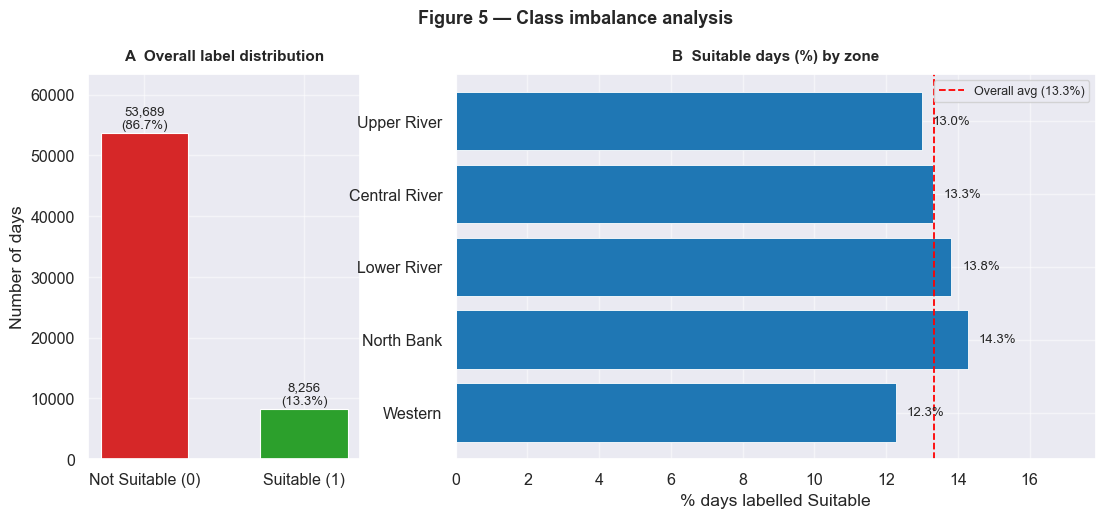

Saved → report/figures/fig5_label_distribution.png


In [7]:
# FIGURE 5 — Label Distribution & Class Imbalance

counts   = df[LABEL_COL].value_counts().sort_index()
labels   = ['Not Suitable (0)', 'Suitable (1)']
colors   = ['#d62728', '#2ca02c']
total    = len(df)

zone_suit = (
    df.groupby(ZONE_COL)[LABEL_COL]
    .mean()
    .mul(100)
    .reindex(ZONES)
)

fig = plt.figure(figsize=(13, 5))
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.35)

# Panel A — overall bar
ax0 = fig.add_subplot(gs[0])
bars = ax0.bar(labels, counts.values, color=colors, edgecolor='white', linewidth=0.8, width=0.55)
ax0.set_title('A  Overall label distribution', fontsize=11, fontweight='bold', pad=10)
ax0.set_ylabel('Number of days')
ax0.set_ylim(0, counts.max() * 1.18)
for bar, val in zip(bars, counts.values):
    ax0.text(bar.get_x() + bar.get_width() / 2, val + total * 0.004,
             f'{val:,}\n({val/total:.1%})', ha='center', va='bottom', fontsize=9.5)

# Panel B — per-zone horizontal bars
ax1 = fig.add_subplot(gs[1:])
hbars = ax1.barh(zone_suit.index, zone_suit.values, color='#1f77b4', edgecolor='white', linewidth=0.6)
avg   = df[LABEL_COL].mean() * 100
ax1.axvline(avg, color='red', linestyle='--', linewidth=1.3, label=f'Overall avg ({avg:.1f}%)')
ax1.set_title('B  Suitable days (%) by zone', fontsize=11, fontweight='bold', pad=10)
ax1.set_xlabel('% days labelled Suitable')
ax1.set_xlim(0, zone_suit.max() * 1.25)
for bar in hbars:
    w = bar.get_width()
    ax1.text(w + 0.3, bar.get_y() + bar.get_height() / 2,
             f'{w:.1f}%', va='center', fontsize=9.5)
ax1.legend(fontsize=9)

fig.suptitle('Figure 5 — Class imbalance analysis', fontsize=13, fontweight='bold', y=1.01)
plt.savefig(FIGURES_DIR / 'fig5_label_distribution.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved → report/figures/fig5_label_distribution.png')

## Label Distribution & Class Imbalance

The Label Distribution figure shows the distribution of suitable and not suitable planting conditions across the dataset, helping identify whether the classes are balanced. The zone-level suitability percentages also highlight regional differences in planting potential across the agricultural zones of The Gambia. Understanding this imbalance is important because it can affect the performance and fairness of the machine learning model.


# Figure 6 — Feature Correlation Heatmap

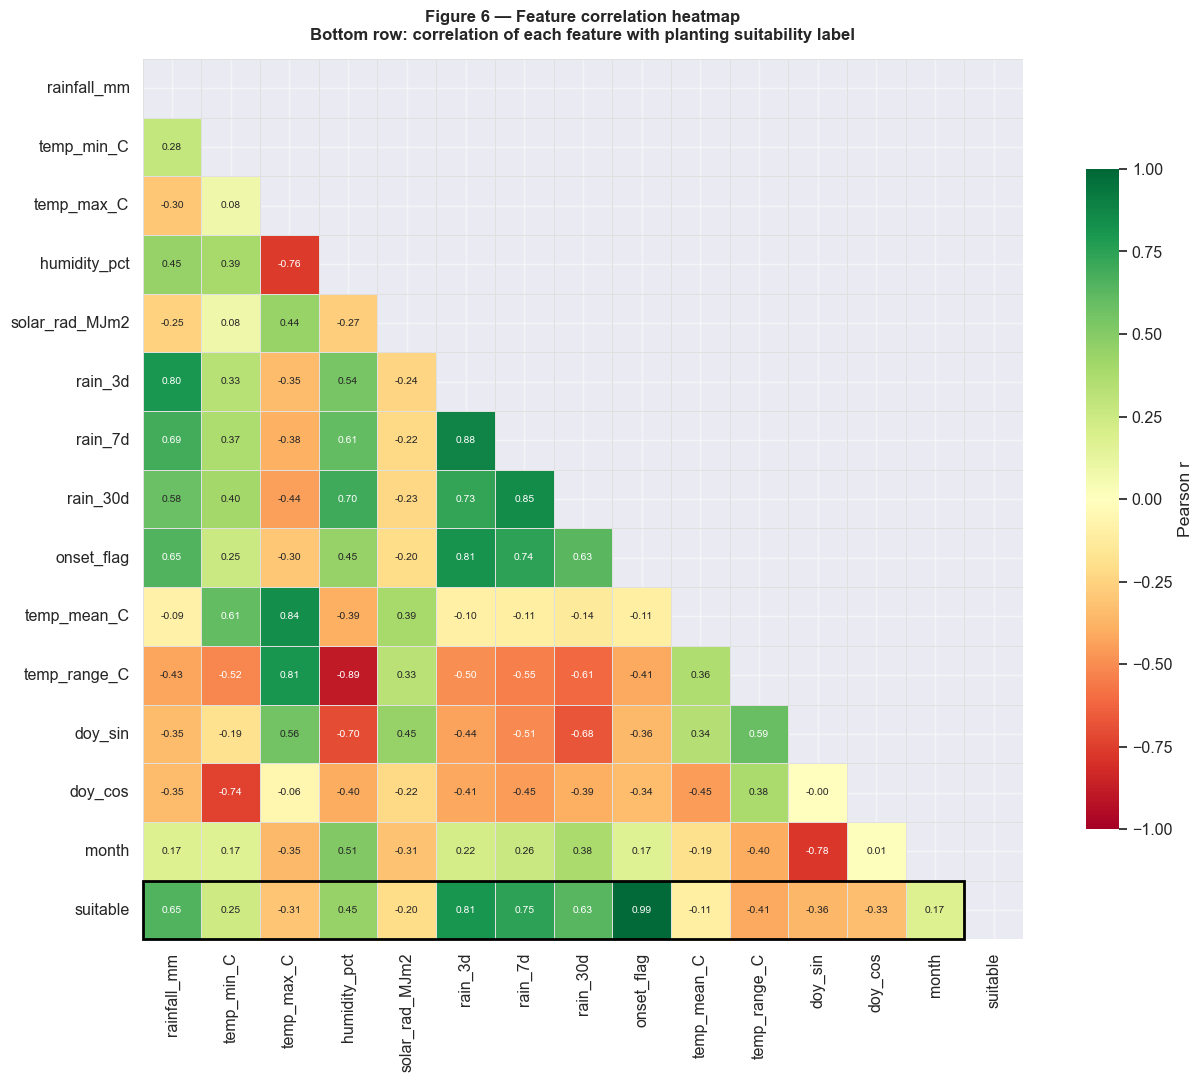

Saved → report/figures/fig6_correlation_heatmap.png


In [12]:
# FIGURE 6 — Feature Correlation Heatmap

CORR_COLS = MODEL_FEATURES + [LABEL_COL]
corr = df[CORR_COLS].corr()

# Mask upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(
    corr, mask=mask,
    annot=True, fmt='.2f', annot_kws={'size': 7.5},
    cmap='RdYlGn', center=0, vmin=-1, vmax=1,
    linewidths=0.4, linecolor='#e0e0e0',
    square=True, ax=ax,
    cbar_kws={'shrink': 0.75, 'label': 'Pearson r'},
)
ax.set_title(
    'Figure 6 — Feature correlation heatmap\n'
    'Bottom row: correlation of each feature with planting suitability label',
    fontsize=12, fontweight='bold', pad=14,
)
# Highlight the label row
ax.add_patch(plt.Rectangle(
    (0, len(CORR_COLS) - 1), len(CORR_COLS) - 1, 1,
    fill=False, edgecolor='black', lw=2, clip_on=False,
))
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig6_correlation_heatmap.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved → report/figures/fig6_correlation_heatmap.png')

## Feature Correlation Heatmap

The correlation heatmap illustrates the relationships between environmental variables such as rainfall, temperature, humidity, and the planting suitability label. Strong positive or negative correlations help identify which factors most influence crop planting decisions in The Gambia. This analysis is useful for feature selection and for understanding how climatic conditions interact with crop suitability.


# FIGURE 7 — Suitability Heatmap by Zone and Month

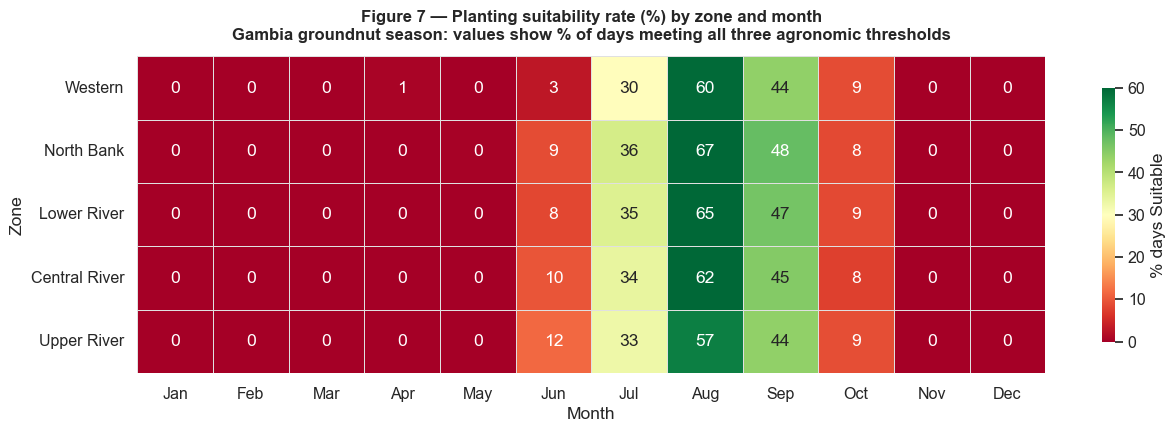

Saved → report/figures/fig7_suitability_heatmap.png


In [13]:
# FIGURE 7 — Suitability Heatmap by Zone and Month

pivot = (
    df.groupby([ZONE_COL, 'month'])[LABEL_COL]
    .mean()
    .mul(100)
    .unstack(level='month')   # columns = months 1-12
    .reindex(ZONES)           # rows in zone order
)

month_labels = ['Jan','Feb','Mar','Apr','May','Jun',
                'Jul','Aug','Sep','Oct','Nov','Dec']

fig, ax = plt.subplots(figsize=(13, 4.5))
sns.heatmap(
    pivot,
    annot=True, fmt='.0f',
    cmap='RdYlGn', vmin=0, vmax=60,
    linewidths=0.5, linecolor='#e0e0e0',
    xticklabels=month_labels,
    cbar_kws={'shrink': 0.8, 'label': '% days Suitable'},
    ax=ax,
)
ax.set_title(
    'Figure 7 — Planting suitability rate (%) by zone and month\n'
    'Gambia groundnut season: values show % of days meeting all three agronomic thresholds',
    fontsize=12, fontweight='bold', pad=12,
)
ax.set_xlabel('Month')
ax.set_ylabel('Zone')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig7_suitability_heatmap.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved → report/figures/fig7_suitability_heatmap.png')

## Suitability Heatmap by Zone and Month

This heatmap visualizes how planting suitability changes across different months and agricultural zones in The Gambia. Seasonal patterns are clearly visible, showing periods where environmental conditions are more favorable for crop planting. The figure helps identify optimal planting windows for each region based on historical climate patterns.


# FIGURE 8 — Annual Rainfall Trend by Zone

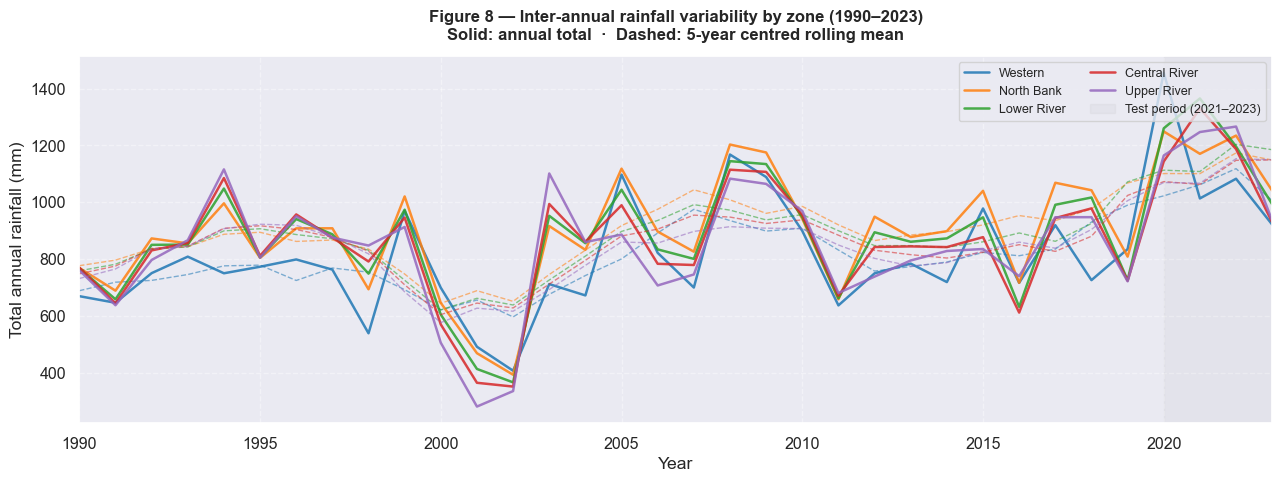

Saved → report/figures/fig8_annual_rainfall_trend.png


In [14]:
# FIGURE 8 — Annual Rainfall Trend by Zone

annual = (
    df.groupby([ZONE_COL, 'year'])['rainfall_mm']
    .sum()
    .unstack(level=ZONE_COL)
    .reindex(columns=ZONES)
)

colors_zone = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

fig, ax = plt.subplots(figsize=(13, 5))

for zone, color in zip(ZONES, colors_zone):
    ax.plot(annual.index, annual[zone],
            label=zone, color=color, linewidth=1.8, alpha=0.85)
    # 5-year rolling mean as dashed overlay
    roll = annual[zone].rolling(5, center=True, min_periods=3).mean()
    ax.plot(annual.index, roll,
            color=color, linewidth=1, linestyle='--', alpha=0.55)

# Shade the monsoon-dominated years for context
ax.axvspan(2020, annual.index.max(), alpha=0.06, color='grey',
           label='Test period (2021–2023)')

ax.set_title(
    'Figure 8 — Inter-annual rainfall variability by zone (1990–2023)\n'
    'Solid: annual total  ·  Dashed: 5-year centred rolling mean',
    fontsize=12, fontweight='bold', pad=12,
)
ax.set_xlabel('Year')
ax.set_ylabel('Total annual rainfall (mm)')
ax.set_xlim(annual.index.min(), annual.index.max())
ax.legend(loc='upper right', fontsize=9, ncol=2)
ax.grid(linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig8_annual_rainfall_trend.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved → report/figures/fig8_annual_rainfall_trend.png')

## Annual Rainfall Trend by Zone

This figure presents yearly rainfall trends across the different agricultural zones, showing how rainfall varies over time and location. Differences in rainfall patterns can significantly influence crop productivity and planting recommendations. The visualization helps assess climate variability and supports data-driven agricultural planning for the Crop Planting Advisor system.

In [15]:
# Cell — Confirmation summary

saved = sorted(FIGURES_DIR.glob('fig[5678]_*.png'))
print('=== EDA COMPLETE ===')
print(f'Dataset : {len(df):,} rows  ·  {df[ZONE_COL].nunique()} zones  ·  {df["year"].nunique()} years')
print()
print('Figures written:')
for f in saved:
    print(f'  report/figures/{f.name}')
print()
print('Next step → P1: run src/train.py to produce models/*.pkl')

=== EDA COMPLETE ===
Dataset : 61,945 rows  ·  5 zones  ·  34 years

Figures written:
  report/figures/fig5_label_distribution.png
  report/figures/fig6_correlation_heatmap.png
  report/figures/fig7_suitability_heatmap.png
  report/figures/fig8_annual_rainfall_trend.png

Next step → P1: run src/train.py to produce models/*.pkl
